In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print("Imports done ✓")

Imports done ✓


In [2]:
df           = pd.read_csv('../data/featured_aqi.csv', parse_dates=['Date'])
rf_model     = joblib.load('../models/random_forest.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')

df = df.sort_values(['City', 'Date']).reset_index(drop=True)

cities = sorted(df['City'].unique())
print(f"Cities     : {len(cities)}")
print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total rows : {len(df):,}")
print(f"\nAll cities:")
for i, c in enumerate(cities, 1):
    print(f"  {i:2}. {c}")

Cities     : 26
Date range : 2015-01-08 → 2020-07-01
Total rows : 24,668

All cities:
   1. Ahmedabad
   2. Aizawl
   3. Amaravati
   4. Amritsar
   5. Bengaluru
   6. Bhopal
   7. Brajrajnagar
   8. Chandigarh
   9. Chennai
  10. Coimbatore
  11. Delhi
  12. Ernakulam
  13. Gurugram
  14. Guwahati
  15. Hyderabad
  16. Jaipur
  17. Jorapokhar
  18. Kochi
  19. Kolkata
  20. Lucknow
  21. Mumbai
  22. Patna
  23. Shillong
  24. Talcher
  25. Thiruvananthapuram
  26. Visakhapatnam


In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

print("Evaluating Random Forest on each city...")
print("-" * 55)

for city in cities:
    city_df   = df[df['City'] == city].copy()
    test_df   = city_df[city_df['Year'] == 2020]

    if len(test_df) < 10:
        print(f"  {city:<22} — skipped (insufficient 2020 data)")
        continue

    X_city = test_df[feature_cols]
    y_city = test_df['AQI']

    # Drop rows with any NaN in features
    mask   = X_city.notna().all(axis=1)
    X_city = X_city[mask]
    y_city = y_city[mask]

    if len(X_city) < 5:
        continue

    preds = rf_model.predict(X_city)
    rmse  = np.sqrt(mean_squared_error(y_city, preds))
    mae   = mean_absolute_error(y_city, preds)
    r2    = r2_score(y_city, preds)
    mean_aqi = y_city.mean()

    results.append({
        'City'     : city,
        'RMSE'     : round(rmse, 2),
        'MAE'      : round(mae, 2),
        'R2'       : round(r2, 4),
        'Mean_AQI' : round(mean_aqi, 1),
        'N_days'   : len(X_city)
    })
    print(f"  {city:<22}  RMSE={rmse:6.1f}  R²={r2:.4f}  n={len(X_city)}")

results_df = pd.DataFrame(results).sort_values('RMSE')
print(f"\nTotal cities evaluated: {len(results_df)}")

Evaluating Random Forest on each city...
-------------------------------------------------------
  Aizawl                  RMSE=   6.5  R²=0.8903  n=104
  Amaravati               RMSE=   8.1  R²=0.8902  n=183
  Amritsar                RMSE=  33.5  R²=0.4844  n=174
  Bengaluru               RMSE=   6.6  R²=0.8854  n=183
  Bhopal                  RMSE=  11.8  R²=0.9061  n=173
  Brajrajnagar            RMSE=  28.5  R²=0.6750  n=121
  Chandigarh              RMSE=   9.0  R²=0.8838  n=182
  Chennai                 RMSE=  10.8  R²=0.7802  n=183
  Coimbatore              RMSE=  10.2  R²=0.7706  n=156
  Delhi                   RMSE=  13.0  R²=0.9793  n=183
  Gurugram                RMSE=  14.7  R²=0.9511  n=183
  Guwahati                RMSE=  19.6  R²=0.9714  n=183
  Hyderabad               RMSE=   6.0  R²=0.9477  n=183
  Jaipur                  RMSE=  11.3  R²=0.7964  n=183
  Kochi                   RMSE=  18.1  R²=0.6883  n=151
  Kolkata                 RMSE=  10.6  R²=0.9810  n=183
  Mumba

In [4]:
print("\n" + "=" * 65)
print("  CITY-WISE MODEL PERFORMANCE — RANKED BY RMSE (Best → Worst)")
print("=" * 65)
print(f"  {'Rank':<5} {'City':<22} {'RMSE':>7} {'MAE':>7} {'R²':>8} {'Avg AQI':>8}")
print(f"  {'-'*60}")

for i, row in results_df.reset_index(drop=True).iterrows():
    flag = " ← best" if i == 0 else (" ← worst" if i == len(results_df)-1 else "")
    print(f"  {i+1:<5} {row['City']:<22} {row['RMSE']:>7.1f} "
          f"{row['MAE']:>7.1f} {row['R2']:>8.4f} {row['Mean_AQI']:>8.1f}{flag}")

print("=" * 65)
print(f"\nBest  predicted city : {results_df.iloc[0]['City']}  "
      f"(RMSE={results_df.iloc[0]['RMSE']})")
print(f"Worst predicted city : {results_df.iloc[-1]['City']}  "
      f"(RMSE={results_df.iloc[-1]['RMSE']})")
print(f"\nOverall RMSE range   : {results_df['RMSE'].min():.1f} → "
      f"{results_df['RMSE'].max():.1f}")
print(f"Overall R² range     : {results_df['R2'].min():.4f} → "
      f"{results_df['R2'].max():.4f}")


  CITY-WISE MODEL PERFORMANCE — RANKED BY RMSE (Best → Worst)
  Rank  City                      RMSE     MAE       R²  Avg AQI
  ------------------------------------------------------------
  1     Hyderabad                  6.0     4.8   0.9477     78.2 ← best
  2     Aizawl                     6.5     5.8   0.8903     33.4
  3     Bengaluru                  6.6     5.2   0.8854     79.7
  4     Mumbai                     7.8     5.7   0.9787    103.6
  5     Amaravati                  8.1     6.2   0.8902     59.9
  6     Chandigarh                 9.0     6.9   0.8838     71.4
  7     Thiruvananthapuram         9.6     5.8   0.7820     66.5
  8     Shillong                   9.7     7.4   0.9040     57.9
  9     Coimbatore                10.2     8.4   0.7706     68.2
  10    Kolkata                   10.6     7.7   0.9810    117.3
  11    Chennai                   10.8     8.2   0.7802     80.3
  12    Jaipur                    11.3     7.5   0.7964    105.1
  13    Bhopal        

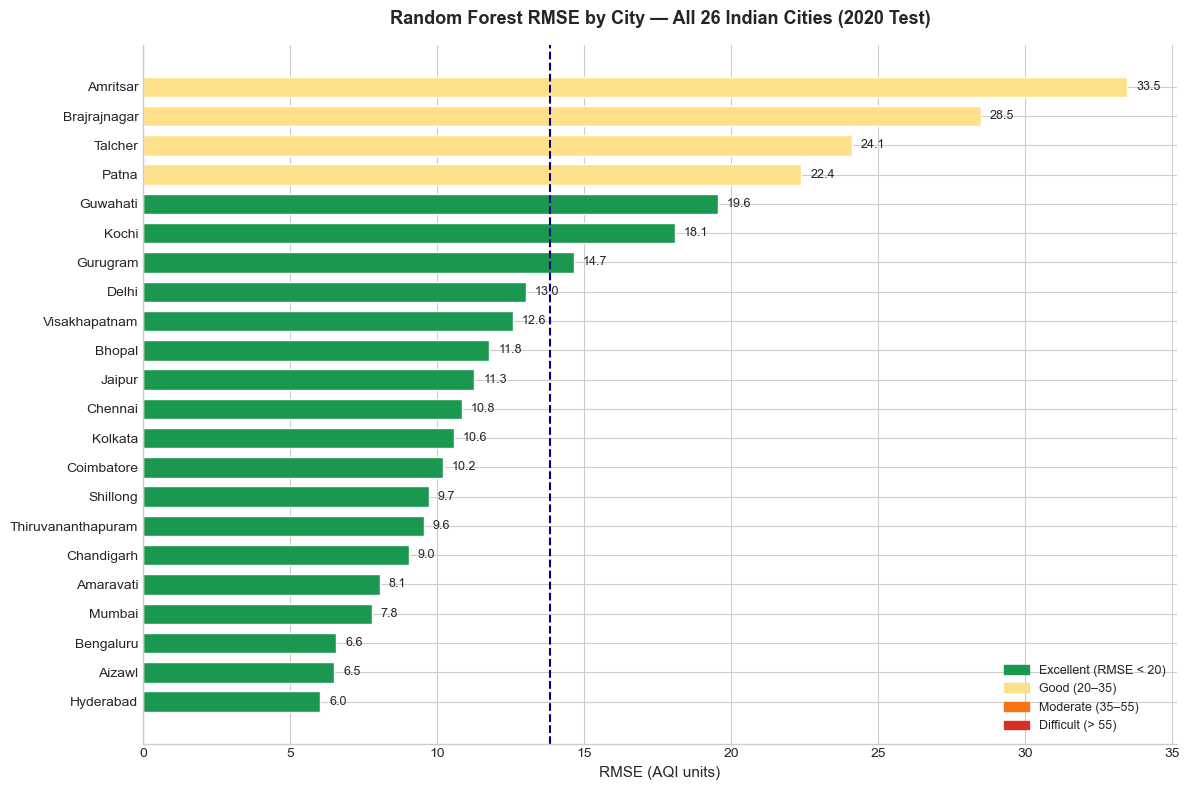

Plot 1 saved ✓


In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

sorted_df = results_df.sort_values('RMSE', ascending=True)
colors = []
for rmse in sorted_df['RMSE']:
    if rmse < 20:   colors.append('#1a9850')   # green — excellent
    elif rmse < 35: colors.append('#fee08b')   # yellow — good
    elif rmse < 55: colors.append('#f97316')   # orange — moderate
    else:           colors.append('#d73027')   # red — difficult

bars = ax.barh(sorted_df['City'], sorted_df['RMSE'],
               color=colors, edgecolor='white', height=0.7)

# Value labels
for bar, val in zip(bars, sorted_df['RMSE']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

# Legend
legend_items = [
    mpatches.Patch(color='#1a9850', label='Excellent (RMSE < 20)'),
    mpatches.Patch(color='#fee08b', label='Good (20–35)'),
    mpatches.Patch(color='#f97316', label='Moderate (35–55)'),
    mpatches.Patch(color='#d73027', label='Difficult (> 55)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)
ax.axvline(results_df['RMSE'].mean(), color='navy', linewidth=1.5,
           linestyle='--', label=f"Avg RMSE: {results_df['RMSE'].mean():.1f}")

ax.set_title('Random Forest RMSE by City — All 26 Indian Cities (2020 Test)',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('RMSE (AQI units)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../visualizations/17_city_rmse_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved ✓")

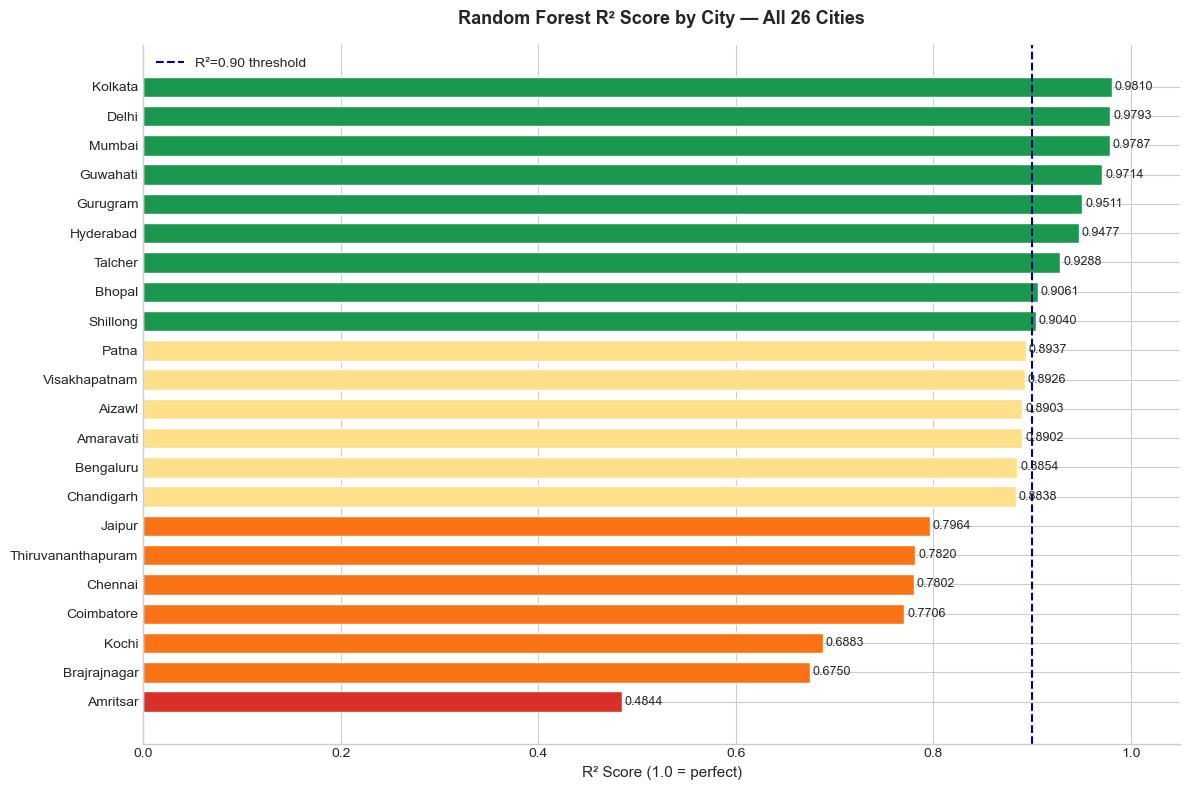

Plot 2 saved ✓


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

sorted_r2 = results_df.sort_values('R2', ascending=True)
r2_colors = ['#1a9850' if r > 0.90 else
             '#fee08b' if r > 0.80 else
             '#f97316' if r > 0.60 else '#d73027'
             for r in sorted_r2['R2']]

bars2 = ax.barh(sorted_r2['City'], sorted_r2['R2'],
                color=r2_colors, edgecolor='white', height=0.7)

for bar, val in zip(bars2, sorted_r2['R2']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(0.90, color='navy', linewidth=1.5, linestyle='--',
           label='R²=0.90 threshold')
ax.set_xlim(0, 1.05)
ax.set_title('Random Forest R² Score by City — All 26 Cities',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('R² Score (1.0 = perfect)', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../visualizations/18_city_r2_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved ✓")

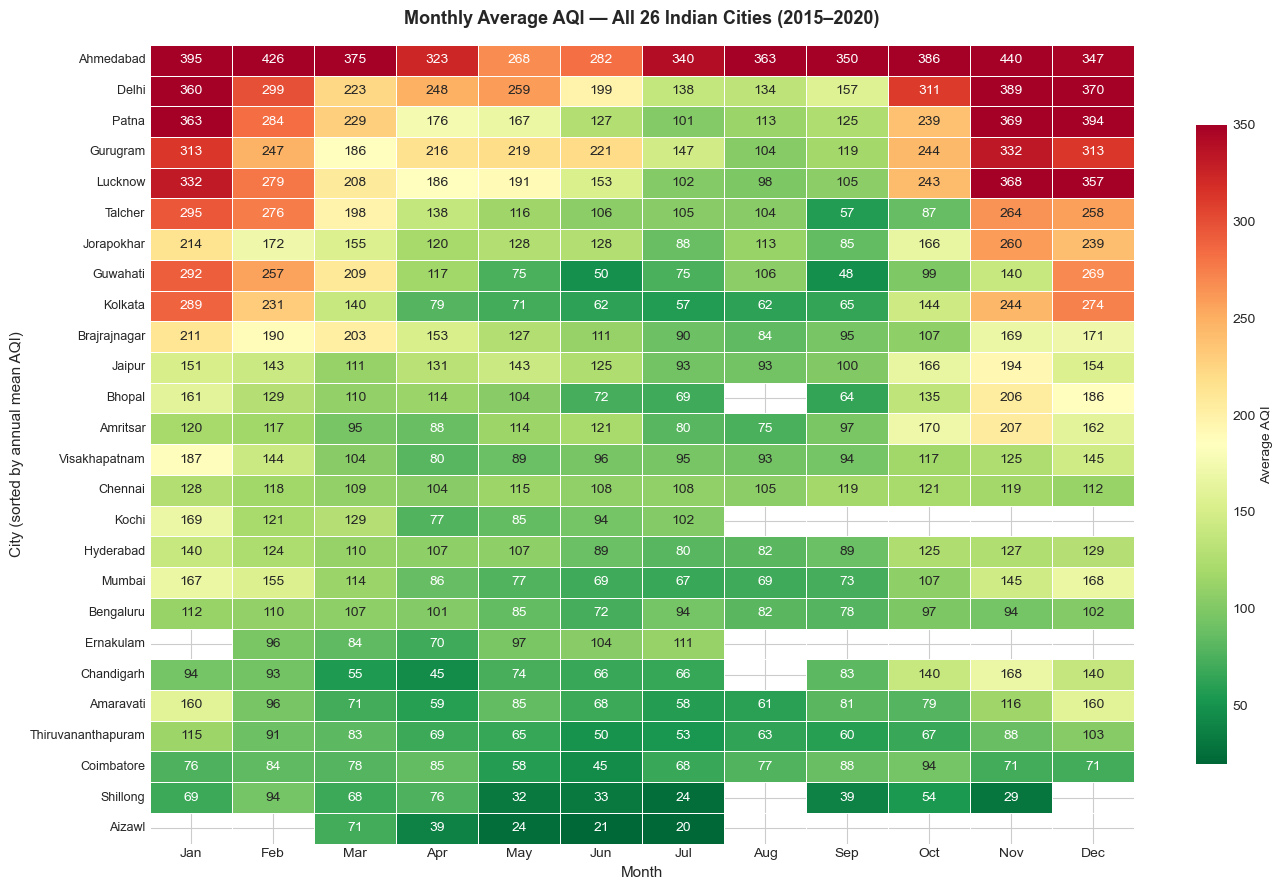

Plot 3 saved ✓  ← this is your most impressive visualization


In [7]:
# Monthly average AQI per city — heatmap
monthly_city = df.groupby(['City', 'Month'])['AQI'].mean().unstack()
monthly_city.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']

# Sort cities by annual mean AQI
city_annual_mean = monthly_city.mean(axis=1).sort_values(ascending=False)
monthly_city = monthly_city.loc[city_annual_mean.index]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    monthly_city,
    annot=True, fmt='.0f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Average AQI', 'shrink': 0.8},
    vmin=20, vmax=350
)
ax.set_title('Monthly Average AQI — All 26 Indian Cities (2015–2020)',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('City (sorted by annual mean AQI)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('../visualizations/19_city_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved ✓  ← this is your most impressive visualization")

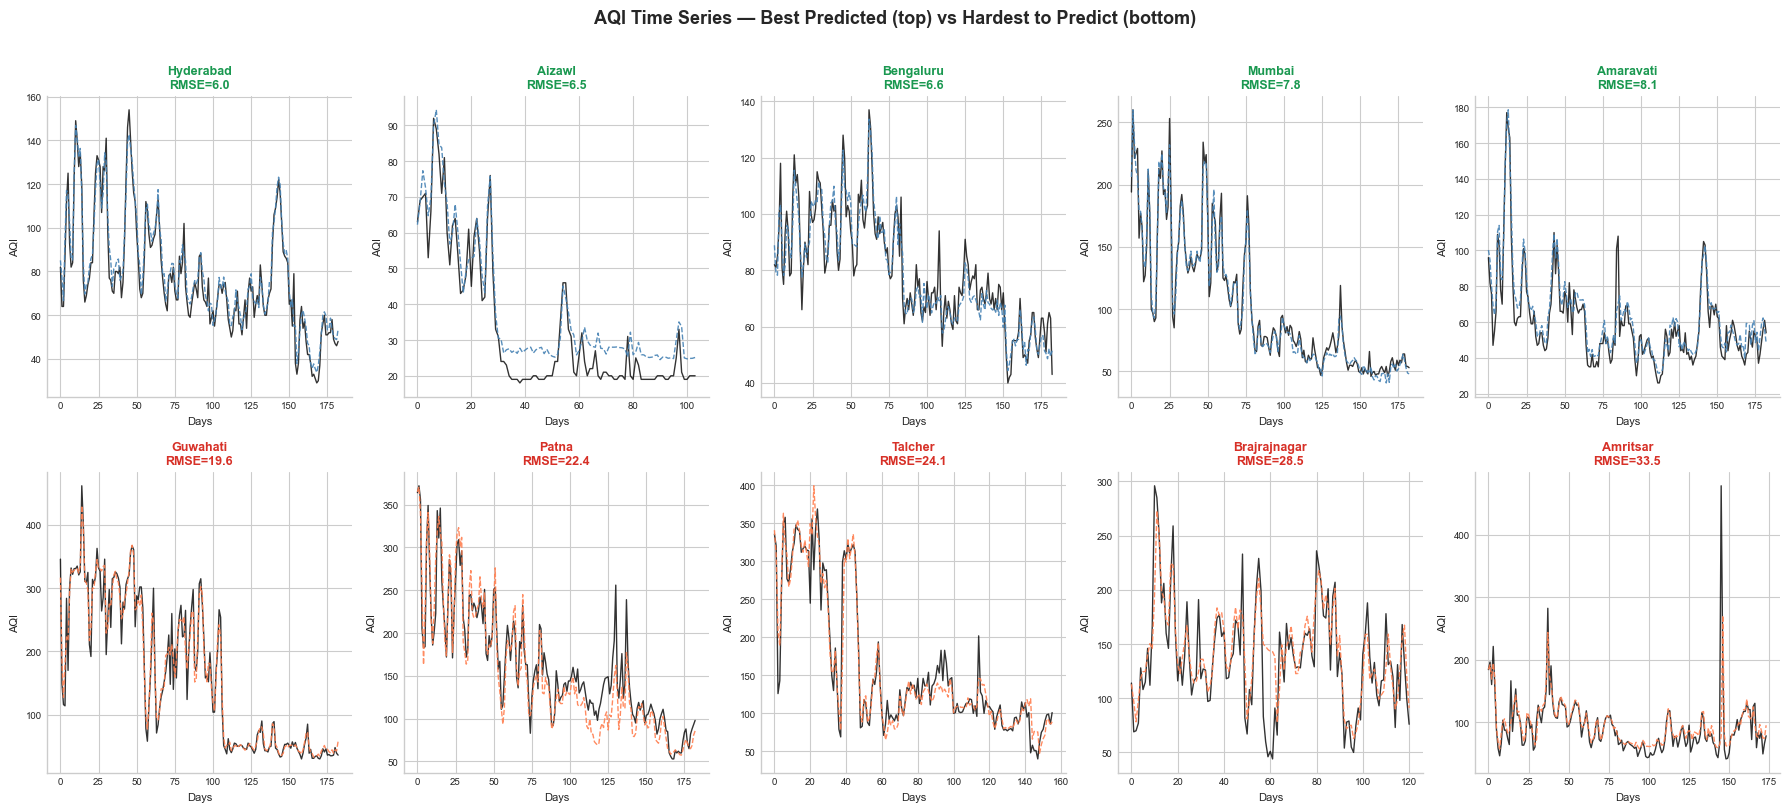

Plot 4 saved ✓


In [8]:
best5  = results_df.head(5)['City'].tolist()
worst5 = results_df.tail(5)['City'].tolist()
compare_cities = best5 + worst5

fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
fig.suptitle('AQI Time Series — Best Predicted (top) vs Hardest to Predict (bottom)',
             fontweight='bold', fontsize=13, y=1.01)

for i, city in enumerate(compare_cities):
    row = 0 if i < 5 else 1
    col = i % 5
    ax  = axes[row][col]

    city_df  = df[df['City'] == city].copy()
    test_df  = city_df[city_df['Year'] == 2020].copy()

    if len(test_df) > 0:
        X_c    = test_df[feature_cols].dropna()
        y_c    = test_df.loc[X_c.index, 'AQI']
        preds  = rf_model.predict(X_c)
        rmse_c = results_df[results_df['City']==city]['RMSE'].values
        rmse_c = rmse_c[0] if len(rmse_c) > 0 else 0

        ax.plot(range(len(y_c)), y_c.values,
                color='black', linewidth=1, alpha=0.8, label='Actual')
        ax.plot(range(len(preds)), preds,
                color='steelblue' if row==0 else 'coral',
                linewidth=1, linestyle='--', alpha=0.9, label='Predicted')

        color = '#1a9850' if row == 0 else '#d73027'
        ax.set_title(f'{city}\nRMSE={rmse_c:.1f}',
                     fontsize=9, fontweight='bold', color=color)
        ax.set_xlabel('Days', fontsize=8)
        ax.set_ylabel('AQI', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../visualizations/20_best_worst_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved ✓")

In [9]:
# Merge results with dataset stats to find patterns
city_stats = df.groupby('City').agg(
    AQI_std    = ('AQI', 'std'),
    AQI_mean   = ('AQI', 'mean'),
    AQI_max    = ('AQI', 'max'),
    data_days  = ('AQI', 'count')
).reset_index()

analysis = results_df.merge(city_stats, on='City')
analysis['CV'] = analysis['AQI_std'] / analysis['AQI_mean']  # coefficient of variation

# Correlation: does high AQI variability = worse predictions?
corr_rmse_std = analysis['RMSE'].corr(analysis['AQI_std'])
corr_rmse_cv  = analysis['RMSE'].corr(analysis['CV'])
corr_rmse_n   = analysis['RMSE'].corr(analysis['data_days'])

print("=" * 50)
print("  WHY SOME CITIES ARE HARDER TO PREDICT")
print("=" * 50)
print(f"""
  Correlation: RMSE vs AQI std deviation : {corr_rmse_std:+.3f}
  Correlation: RMSE vs AQI variability   : {corr_rmse_cv:+.3f}
  Correlation: RMSE vs data availability : {corr_rmse_n:+.3f}
""")

if corr_rmse_std > 0.3:
    print("  Finding: Cities with HIGH AQI variability are")
    print("  harder to predict — pollution spikes are less")
    print("  predictable from historical patterns alone.")

print("\n  Top 3 most variable cities (hardest to predict):")
top_var = analysis.nlargest(3, 'AQI_std')[['City','AQI_std','RMSE']]
for _, row in top_var.iterrows():
    print(f"    {row['City']:<22} std={row['AQI_std']:.1f}  RMSE={row['RMSE']:.1f}")

print("\n  Top 3 most stable cities (easiest to predict):")
top_stable = analysis.nsmallest(3, 'AQI_std')[['City','AQI_std','RMSE']]
for _, row in top_stable.iterrows():
    print(f"    {row['City']:<22} std={row['AQI_std']:.1f}  RMSE={row['RMSE']:.1f}")

  WHY SOME CITIES ARE HARDER TO PREDICT

  Correlation: RMSE vs AQI std deviation : +0.471
  Correlation: RMSE vs AQI variability   : +0.207
  Correlation: RMSE vs data availability : -0.047

  Finding: Cities with HIGH AQI variability are
  harder to predict — pollution spikes are less
  predictable from historical patterns alone.

  Top 3 most variable cities (hardest to predict):
    Patna                  std=120.9  RMSE=22.4
    Delhi                  std=115.9  RMSE=13.0
    Gurugram               std=115.5  RMSE=14.7

  Top 3 most stable cities (easiest to predict):
    Coimbatore             std=18.2  RMSE=10.2
    Aizawl                 std=19.7  RMSE=6.5
    Shillong               std=28.4  RMSE=9.7


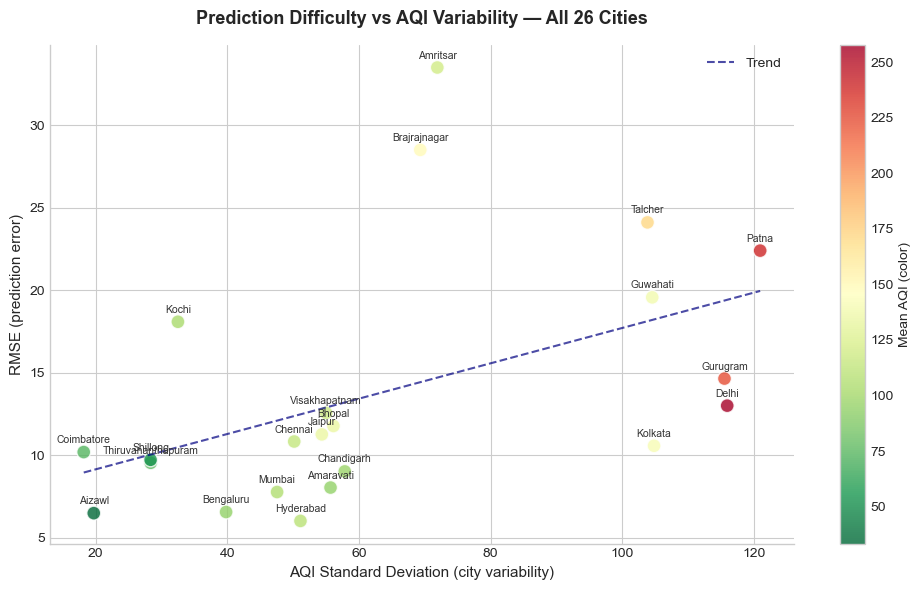

Plot 5 saved ✓


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    analysis['AQI_std'], analysis['RMSE'],
    c=analysis['AQI_mean'], cmap='RdYlGn_r',
    s=100, alpha=0.8, edgecolors='white', linewidth=1
)
plt.colorbar(scatter, label='Mean AQI (color)')

# Label each city
for _, row in analysis.iterrows():
    ax.annotate(row['City'],
                (row['AQI_std'], row['RMSE']),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                color='#333')

# Trend line
z = np.polyfit(analysis['AQI_std'], analysis['RMSE'], 1)
p = np.poly1d(z)
x_line = np.linspace(analysis['AQI_std'].min(), analysis['AQI_std'].max(), 100)
ax.plot(x_line, p(x_line), 'navy', linewidth=1.5,
        linestyle='--', alpha=0.7, label='Trend')

ax.set_title('Prediction Difficulty vs AQI Variability — All 26 Cities',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('AQI Standard Deviation (city variability)', fontsize=11)
ax.set_ylabel('RMSE (prediction error)', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../visualizations/21_rmse_vs_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved ✓")

In [11]:
results_df.to_csv('../data/multicity_results.csv', index=False)
analysis.to_csv('../data/multicity_analysis.csv', index=False)

print("Saved:")
print("  data/multicity_results.csv   ← RMSE/MAE/R² per city")
print("  data/multicity_analysis.csv  ← full analysis with variability")
print()
print("Visualizations saved:")
viz_new = ['17_city_rmse_ranking.png','18_city_r2_ranking.png',
           '19_city_monthly_heatmap.png','20_best_worst_cities.png',
           '21_rmse_vs_variability.png']
for v in viz_new:
    print(f"  visualizations/{v} ✓")

Saved:
  data/multicity_results.csv   ← RMSE/MAE/R² per city
  data/multicity_analysis.csv  ← full analysis with variability

Visualizations saved:
  visualizations/17_city_rmse_ranking.png ✓
  visualizations/18_city_r2_ranking.png ✓
  visualizations/19_city_monthly_heatmap.png ✓
  visualizations/20_best_worst_cities.png ✓
  visualizations/21_rmse_vs_variability.png ✓


In [12]:
best_city  = results_df.iloc[0]
worst_city = results_df.iloc[-1]
above_90   = (results_df['R2'] >= 0.90).sum()
print(f"""
  Cities evaluated    : {len(results_df)} / 26
  Cities with R² ≥ 0.90 : {above_90} cities

  Best predicted      : {best_city['City']}
    RMSE={best_city['RMSE']}  R²={best_city['R2']}

  Hardest to predict  : {worst_city['City']}
    RMSE={worst_city['RMSE']}  R²={worst_city['R2']}

  Overall RMSE avg    : {results_df['RMSE'].mean():.1f}
  Overall R² avg      : {results_df['R2'].mean():.4f}

  Key finding:
  Cities with high AQI variability are harder
  to predict — pollution spikes from industrial
  activity or festivals are less foreseeable from
  historical patterns alone.

  Plots: 17 → 21 saved to visualizations/
  Data : multicity_results.csv saved to data/
""")
print("=" * 55)


  Cities evaluated    : 22 / 26
  Cities with R² ≥ 0.90 : 9 cities

  Best predicted      : Hyderabad
    RMSE=6.03  R²=0.9477

  Hardest to predict  : Amritsar
    RMSE=33.49  R²=0.4844

  Overall RMSE avg    : 13.8
  Overall R² avg      : 0.8573

  Key finding:
  Cities with high AQI variability are harder
  to predict — pollution spikes from industrial
  activity or festivals are less foreseeable from
  historical patterns alone.

  Plots: 17 → 21 saved to visualizations/
  Data : multicity_results.csv saved to data/

